In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

In [2]:
import langchain
import groq
import os

from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.runnables import Runnable
from langchain_core.messages import HumanMessage, BaseMessage
from collections.abc import Sequence

In [3]:
class State(TypedDict):
    messages:Sequence[BaseMessage]

In [4]:
state = State(messages = [HumanMessage('Could you tell me a grook by Piet Hein?')])

In [5]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Could you tell me a grook by Piet Hein?


In [6]:
chat = ChatGroq(
    model_name="llama-3.1-8b-instant",  # Groq model
    temperature=0,
    seed=365,
    max_tokens=100,
    groq_api_key=os.getenv("GROQ_API_KEY"),  # remove if already set globally
)

C:\Users\HetviDesai\anaconda3\envs\langgraph_env\Lib\site-packages\pydantic\main.py:250: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [7]:
response = chat.invoke(state["messages"])

In [8]:
response.pretty_print()

================================== Ai Message ==================================

Piet Hein was a Danish poet known for his short, witty poems called "grooks." Here's one example:

"Life is not a problem to be solved,
But a reality to be experienced.
The answer lies not in the solution,
But in the living of the question."

This grook captures the essence of living in the moment and finding meaning in the experience itself, rather than seeking a specific outcome or solution.


In [9]:
def chatbot(state: State) -> State:
    print(f"\n-------> ENTERING CHATBOT:")
    response = chat.invoke(state["messages"]) 
    response.pretty_print()

    return State(messages = [response])

In [10]:
chatbot(state)


-------> ENTERING CHATBOT:
================================== Ai Message ==================================

Piet Hein was a Danish poet known for his short, witty poems called "grooks." Here's one example:

"Life is not a problem to be solved,
But a reality to be experienced.
The answer lies not in the solution,
But in the living of the question."

This grook captures the essence of living in the moment and finding meaning in the experience itself, rather than seeking a specific outcome or solution.


{'messages': [AIMessage(content='Piet Hein was a Danish poet known for his short, witty poems called "grooks." Here\'s one example:\n\n"Life is not a problem to be solved,\nBut a reality to be experienced.\nThe answer lies not in the solution,\nBut in the living of the question."\n\nThis grook captures the essence of living in the moment and finding meaning in the experience itself, rather than seeking a specific outcome or solution.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 46, 'total_tokens': 132, 'completion_time': 0.238410126, 'completion_tokens_details': None, 'prompt_time': 0.00214258, 'prompt_tokens_details': None, 'queue_time': 0.04618347, 'total_time': 0.240552706}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d51a8-8ec2-7953-9c4d-d6b48f438fb6-0', tool_calls=[], invalid_tool_

In [11]:
graph = StateGraph(State)

In [12]:
graph.add_node("chatbot", chatbot)

In [13]:
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [14]:
graph_compiled = graph.compile()

In [16]:
isinstance(graph_compiled, Runnable)

True

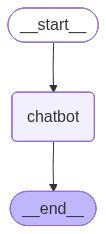

In [17]:
graph_compiled

In [18]:
graph_compiled.invoke(state)


-------> ENTERING CHATBOT:
================================== Ai Message ==================================

Piet Hein was a Danish poet known for his short, witty poems called "grooks." Here's one example:

"Life is not a problem to be solved,
But a reality to be experienced.
The answer lies not in the solution,
But in the living of the question."

This grook captures the essence of living in the moment and finding meaning in the experience itself, rather than seeking a specific outcome or solution.


{'messages': [AIMessage(content='Piet Hein was a Danish poet known for his short, witty poems called "grooks." Here\'s one example:\n\n"Life is not a problem to be solved,\nBut a reality to be experienced.\nThe answer lies not in the solution,\nBut in the living of the question."\n\nThis grook captures the essence of living in the moment and finding meaning in the experience itself, rather than seeking a specific outcome or solution.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 46, 'total_tokens': 132, 'completion_time': 0.157070201, 'completion_tokens_details': None, 'prompt_time': 0.002385774, 'prompt_tokens_details': None, 'queue_time': 0.045977856, 'total_time': 0.159455975}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d51ab-cb24-7143-b134-51f08fbd6284-0', tool_calls=[], invalid_too

In [19]:
%mypy

    chat = ChatGroq(
error: Unexpected keyword argument "model_name" for "ChatGroq"  [call-arg]
    chat = ChatGroq(
error: Unexpected keyword argument "seed" for "ChatGroq"  [call-arg]
    chat = ChatGroq(
error: Unexpected keyword argument "groq_api_key" for "ChatGroq"  [call-arg]
Found 3 errors in 1 file (checked 1 source file)


Type checking failed
